In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harishkumardatalab/food-image-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.68G/1.68G [00:44<00:00, 40.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/harishkumardatalab/food-image-classification-dataset/versions/1


In [ ]:
import os

# Check dataset folder structure
# Note: kagglehub usually downloads to a root folder; we need to find the directory containing image classes
def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        if len(files) > 0:
            print(f'{subindent}{len(files)} files found.')
        if level >= 2: break # Only view basic structure

list_files(path)

1/
    Food Classification dataset/
        pav_bhaji/
            305 files found.


In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# Fix: Point to the actual directory containing the food categories
dataset_root = os.path.join(path, "Food Classification dataset")

all_images = []
all_labels = []

# Iterate through subdirectories (each directory is a label/food category)
if os.path.exists(dataset_root):
    for category in os.listdir(dataset_root):
        category_path = os.path.join(dataset_root, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_images.append(os.path.join(category_path, img_name))
                    all_labels.append(category)

# Check if data was found
if len(all_images) == 0:
    print("Error: No images found. Please check the directory structure.")
else:
    # Create a DataFrame for easier management
    df = pd.DataFrame({'image_path': all_images, 'label': all_labels})

    # Split the dataset into 80% Train and 20% Test
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=df['label']
    )

    print(f"Total images found: {len(df)}")
    print(f"Number of images in Train set: {len(train_df)}")
    print(f"Number of images in Test set: {len(test_df)}")

    # Display the first 5 rows of the Train set
    display(train_df.head())

Total images found: 23873
Number of images in Train set: 19098
Number of images in Test set: 4775


,image_path,label
9029,/root/.cache/kagglehub/datasets/harishkumardat...,Crispy Chicken
8859,/root/.cache/kagglehub/datasets/harishkumardat...,Crispy Chicken
6670,/root/.cache/kagglehub/datasets/harishkumardat...,Hot Dog
11078,/root/.cache/kagglehub/datasets/harishkumardat...,Taco
11201,/root/.cache/kagglehub/datasets/harishkumardat...,Taco


### 1. Check GPU Availability

First, let's verify if a GPU is available for training the model. Utilizing a GPU significantly speeds up the training process for deep learning models like AlexNet.

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Number of GPUs available: {len(gpus)}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Found GPU: {gpu.name}")
else:
    print("No GPU devices found. Training will run on CPU.")

Number of GPUs available: 1
Found GPU: /physical_device:GPU:0


### 2. Build AlexNet Model

Next, we will define the AlexNet architecture using Keras. AlexNet is a classic convolutional neural network known for its architecture that includes stacked convolutional layers, max-pooling, and fully connected layers.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define image dimensions and number of classes
IMG_HEIGHT = 224
IMG_WIDTH = 224
NUM_CLASSES = len(df['label'].unique())

def build_alexnet_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES):
    model = Sequential([
        # First Convolutional Block
        Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=input_shape, padding='valid'),
        MaxPooling2D((3, 3), strides=(2, 2), padding='valid'),
        # Second Convolutional Block
        Conv2D(256, (5, 5), activation='relu', padding='same'),
        MaxPooling2D((3, 3), strides=(2, 2), padding='valid'),
        # Third Convolutional Block
        Conv2D(384, (3, 3), activation='relu', padding='same'),
        # Fourth Convolutional Block
        Conv2D(384, (3, 3), activation='relu', padding='same'),
        # Fifth Convolutional Block
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((3, 3), strides=(2, 2), padding='valid'),
        # Flatten and Fully Connected Layers
        Flatten(),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax') # Output layer for classification
    ])

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

alexnet_model = build_alexnet_model()
alexnet_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 34)             │       139,298 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,886,306 (178.86 MB)

 Trainable params: 46,886,306 (178.86 MB)

 Non-trainable params: 0 (0.00 B)

### 3. Train the Model on the Image Dataset

We will now prepare the image data using `ImageDataGenerator` for augmentation and then train the AlexNet model. Data augmentation helps in preventing overfitting and improving the model's generalization capabilities.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 32

# Data Augmentation and Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Prepare data generators from DataFrames
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Train the model
EPOCHS = 10 # You can adjust this number
history = alexnet_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE
)

Found 19098 validated image filenames belonging to 34 classes.
Found 4775 validated image filenames belonging to 34 classes.
Epoch 1/10
481/596 ━━━━━━━━━━━━━━━━━━━━ 1:08 592ms/step - accuracy: 0.0714 - loss: 3.2744

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


596/596 ━━━━━━━━━━━━━━━━━━━━ 390s 635ms/step - accuracy: 0.0938 - loss: 3.1809 - val_accuracy: 0.1128 - val_loss: 3.0135
Epoch 2/10
  1/596 ━━━━━━━━━━━━━━━━━━━━ 45s 77ms/step - accuracy: 0.1250 - loss: 2.7881

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


596/596 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.1250 - loss: 2.7881 - val_accuracy: 0.1172 - val_loss: 2.9924
Epoch 3/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 365s 611ms/step - accuracy: 0.1558 - loss: 2.8997 - val_accuracy: 0.1865 - val_loss: 2.7622
Epoch 4/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.2188 - loss: 2.9174 - val_accuracy: 0.1915 - val_loss: 2.7496
Epoch 5/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 369s 620ms/step - accuracy: 0.2101 - loss: 2.7107 - val_accuracy: 0.2529 - val_loss: 2.5194
Epoch 6/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.4062 - loss: 2.3341 - val_accuracy: 0.2464 - val_loss: 2.5538
Epoch 7/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 382s 641ms/step - accuracy: 0.2530 - loss: 2.5671 - val_accuracy: 0.2760 - val_loss: 2.4628
Epoch 8/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.3125 - loss: 2.7057 - val_accuracy: 0.2724 - val_loss: 2.4877
Epoch 9/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 366s 614ms/step - accuracy: 0.2828 - loss: 2.4464 - val

### 4. Summarize Training Results

After training, let's evaluate the model's performance on the test set and display the final accuracy and loss.

In [ ]:
loss, accuracy = alexnet_model.evaluate(test_generator)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

150/150 ━━━━━━━━━━━━━━━━━━━━ 27s 177ms/step - accuracy: 0.3577 - loss: 2.2378

Test Loss: 2.2378
Test Accuracy: 0.3577


### 5. Display Training Plots

Visualizing the training and validation accuracy and loss over epochs helps us understand how well the model learned and if there are signs of overfitting or underfitting.

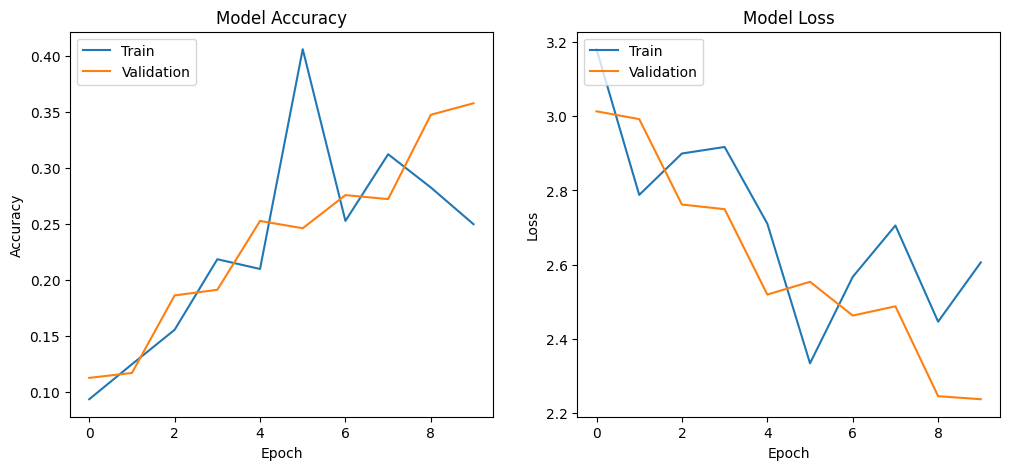

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()